# Visualización de Resultados de Limpieza - Capa Silver

## Descripción

Este notebook visualiza los resultados del proceso de **limpieza y validación de datos** realizado durante la transformación de la **capa Bronze** hacia la **capa Silver**.

A partir de los reportes de calidad generados por el script `bronze_to_silver.py`, se presentan indicadores que permiten evaluar el impacto de las reglas de limpieza y la aplicación de las dimensiones de calidad sobre los datasets procesados.

---

## Objetivos

- Visualizar los resultados de limpieza por tipo de servicio y año.
- Evaluar la efectividad de las dimensiones de calidad aplicadas.
- Comparar el estado de los datos antes y después del proceso de limpieza.
- Validar la integridad y consistencia de los datos almacenados en la capa Silver.

---

## Fuente de datos

| Elemento | Descripción |
|----------|-------------|
| **Origen** | Reportes de calidad generados por `bronze_to_silver.py`. |
| **Ubicación** | `data/silver/cleaning/_quality_reports/` |
| **Cobertura temporal** | 2023, 2024 y 2025. |
| **Datasets** | Yellow Taxi, Green Taxi, FHV y FHVHV. |

---

> **Resultado esperado:** Verificar que las reglas de limpieza hayan mejorado la calidad de los datos y que los datasets de la **capa Silver** cumplan con los criterios de completitud, consistencia, validez, precisión e integridad establecidos para el proyecto.

In [1]:
import os
import json
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Colores institucionales
COLORS = {
    'yellow': '#F4D03F',
    'green': '#58D68D',
    'fhv': '#5DADE2',
    'fhvhv': '#E74C3C',
    'primary': '#2E86AB',
    'success': '#27AE60',
    'warning': '#F39C12',
    'danger': '#E74C3C',
    'excluded': '#95A5A6'
}

# Dimensiones de calidad
QUALITY_DIMENSIONS = [
    'completitud',
    'unicidad',
    'exactitud',
    'razonabilidad',
    'validez',
    'oportunidad'
]

DIMENSION_LABELS = {
    'completitud': 'Completitud',
    'unicidad': 'Unicidad',
    'exactitud': 'Exactitud',
    'razonabilidad': 'Razonabilidad',
    'validez': 'Validez',
    'oportunidad': 'Oportunidad'
}

# ============================================================
# CONFIGURACIÓN DE RUTAS
# ============================================================

def get_project_root():
    current = Path.cwd()
    while current != current.parent:
        if (current / "data" / "bronze").exists():
            return current
        current = current.parent
    return Path.cwd()

ROOT_DIR = get_project_root()
QUALITY_DIR = ROOT_DIR / "data" / "silver" / "cleaning" / "_quality_reports"
OUTPUT_DIR = ROOT_DIR / "data" / "silver" / "cleaned"

print("=" * 80)
print(" VISUALIZACIÓN - RESULTADOS DE LIMPIEZA")
print("=" * 80)
print(f" Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" Reportes: {QUALITY_DIR}")

if not QUALITY_DIR.exists():
    print("\n❌ ERROR: No se encontraron reportes.")
    print("   Ejecuta primero: bronze_to_silver.py")
    exit()

 VISUALIZACIÓN - RESULTADOS DE LIMPIEZA
 Fecha: 2026-07-17 01:42:22
 Reportes: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\cleaning\_quality_reports


In [5]:
# ============================================================
# CARGA DE REPORTES DE CALIDAD
# ============================================================

YEARS = [2023, 2024, 2025]
TAXI_TYPES = ['yellow', 'green', 'fhv', 'fhvhv']
EXCLUDED_TYPES = ['fhvhv']

def load_quality_report(taxi_type, year):
    """Carga un reporte de calidad para un tipo y año específico"""
    path = QUALITY_DIR / f"{taxi_type}_{year}_quality_report.json"
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_all_reports():
    """Carga todos los reportes disponibles"""
    reports = {}
    for taxi_type in TAXI_TYPES:
        reports[taxi_type] = {}
        for year in YEARS:
            report = load_quality_report(taxi_type, year)
            if report:
                reports[taxi_type][year] = report
    return reports

print(" Cargando reportes de calidad...")
ALL_REPORTS = load_all_reports()

# Contar reportes - CORREGIDO: usar ALL_REPORTS en lugar de reports
total_reports = 0
for taxi_type in TAXI_TYPES:
    if taxi_type in ALL_REPORTS:
        total_reports += len(ALL_REPORTS[taxi_type])

print(f" Reportes cargados: {total_reports}")

print("\n Disponibilidad de reportes:")
for taxi_type in TAXI_TYPES:
    if taxi_type in ALL_REPORTS:
        years_found = list(ALL_REPORTS[taxi_type].keys())
        status = "✅" if years_found else "❌"
        excluded = " (EXCLUIDO)" if taxi_type in EXCLUDED_TYPES else ""
        print(f"   {status} {taxi_type.upper()}{excluded}: {years_found if years_found else 'Sin datos'}")
    else:
        print(f"   ❌ {taxi_type.upper()}: No disponible")

 Cargando reportes de calidad...
 Reportes cargados: 9

 Disponibilidad de reportes:
   ✅ YELLOW: [2023, 2024, 2025]
   ✅ GREEN: [2023, 2024, 2025]
   ✅ FHV: [2023, 2024, 2025]
   ❌ FHVHV (EXCLUIDO): Sin datos


 1. RESUMEN GENERAL DE LIMPIEZA

 Resumen de Limpieza por Tipo y Año:
  Tipo  Año  Original  Removidos    Final  Eliminado %  Calidad % Estado
YELLOW 2023  38310226    2757960 35552266         7.20      92.80 ACTIVO
YELLOW 2024  41169720    5627746 35541974        13.67      86.33 ACTIVO
YELLOW 2025  48722602   13807915 34914687        28.34      71.66 ACTIVO
 GREEN 2023    787060     103669   683391        13.17      86.83 ACTIVO
 GREEN 2024    660218      68671   591547        10.40      89.60 ACTIVO
 GREEN 2025    591375      83380   507995        14.10      85.90 ACTIVO
   FHV 2023  15858639     339594 15519045         2.14      97.86 ACTIVO
   FHV 2024  17630326     455131 17175195         2.58      97.42 ACTIVO
   FHV 2025  25047544     607001 24440543         2.42      97.58 ACTIVO


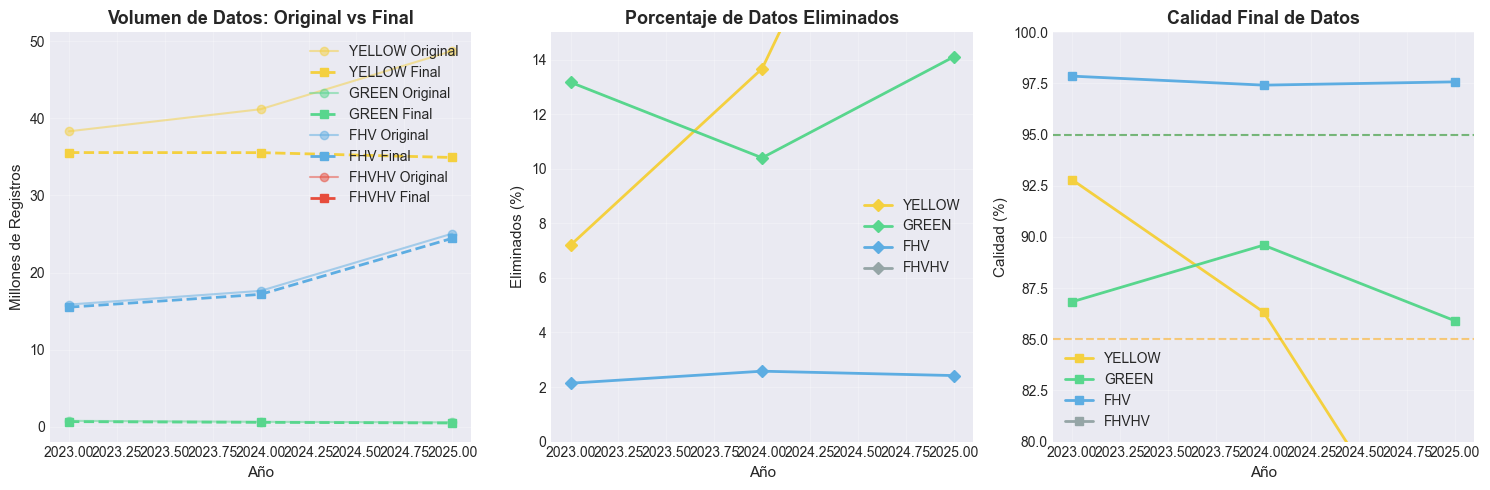

In [8]:
# ============================================================
# 1. RESUMEN GENERAL DE LIMPIEZA
# ============================================================

print("=" * 80)
print(" 1. RESUMEN GENERAL DE LIMPIEZA")
print("=" * 80)

summary_data = []
for taxi_type, years_data in ALL_REPORTS.items():
    for year, report in years_data.items():
        is_excluded = taxi_type in EXCLUDED_TYPES
        removed_pct = report.get('removed_percentage', 0)
        quality_score = 100 - removed_pct
        
        summary_data.append({
            'Tipo': taxi_type.upper(),
            'Año': year,
            'Original': report.get('original_records', 0),
            'Removidos': report.get('records_removed', 0),
            'Final': report.get('final_records', 0),
            'Eliminado %': removed_pct,
            'Calidad %': quality_score,
            'Estado': 'EXCLUIDO' if is_excluded else 'ACTIVO'
        })

df_summary = pd.DataFrame(summary_data)

print("\n Resumen de Limpieza por Tipo y Año:")
print(df_summary.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 1: Registros originales vs finales
ax1 = axes[0]
for taxi_type in TAXI_TYPES:
    if taxi_type not in ALL_REPORTS:
        continue
    years_data = ALL_REPORTS[taxi_type]
    years = sorted(years_data.keys())
    original = [years_data[y].get('original_records', 0) / 1_000_000 for y in years]
    final = [years_data[y].get('final_records', 0) / 1_000_000 for y in years]
    
    color = COLORS.get(taxi_type, COLORS['primary'])
    ax1.plot(years, original, marker='o', linestyle='-', 
             label=f'{taxi_type.upper()} Original', color=color, alpha=0.5)
    ax1.plot(years, final, marker='s', linestyle='--', 
             label=f'{taxi_type.upper()} Final', color=color, linewidth=2)

ax1.set_title('Volumen de Datos: Original vs Final', fontsize=13, fontweight='bold')
ax1.set_xlabel('Año', fontsize=11)
ax1.set_ylabel('Millones de Registros', fontsize=11)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.25)

# Gráfico 2: Porcentaje de datos eliminados
ax2 = axes[1]
for taxi_type in TAXI_TYPES:
    if taxi_type not in ALL_REPORTS:
        continue
    years_data = ALL_REPORTS[taxi_type]
    years = sorted(years_data.keys())
    removed = [years_data[y].get('removed_percentage', 0) for y in years]
    
    color = COLORS.get(taxi_type, COLORS['primary'])
    if taxi_type in EXCLUDED_TYPES:
        color = COLORS['excluded']
    
    ax2.plot(years, removed, marker='D', linestyle='-', linewidth=2,
             label=f'{taxi_type.upper()}', color=color)

ax2.set_title('Porcentaje de Datos Eliminados', fontsize=13, fontweight='bold')
ax2.set_xlabel('Año', fontsize=11)
ax2.set_ylabel('Eliminados (%)', fontsize=11)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.25)
ax2.set_ylim(0, 15)

# Gráfico 3: Calidad final
ax3 = axes[2]
for taxi_type in TAXI_TYPES:
    if taxi_type not in ALL_REPORTS:
        continue
    years_data = ALL_REPORTS[taxi_type]
    years = sorted(years_data.keys())
    quality = [100 - years_data[y].get('removed_percentage', 0) for y in years]
    
    color = COLORS.get(taxi_type, COLORS['primary'])
    if taxi_type in EXCLUDED_TYPES:
        color = COLORS['excluded']
    
    ax3.plot(years, quality, marker='s', linestyle='-', linewidth=2,
             label=f'{taxi_type.upper()}', color=color)

ax3.set_title('Calidad Final de Datos', fontsize=13, fontweight='bold')
ax3.set_xlabel('Año', fontsize=11)
ax3.set_ylabel('Calidad (%)', fontsize=11)
ax3.legend(loc='best')
ax3.grid(True, alpha=0.25)
ax3.axhline(y=95, color='green', linestyle='--', alpha=0.5, label='Excelente')
ax3.axhline(y=85, color='orange', linestyle='--', alpha=0.5, label='Aceptable')
ax3.set_ylim(80, 100)

plt.tight_layout()
plt.show()

 2. ANÁLISIS DETALLADO POR TIPO DE TAXI

 YELLOW

 Resumen por Año:
 Año  Original    Final  Eliminados  Eliminado %  Completitud  Unicidad  Exactitud  Razonabilidad  Validez  Oportunidad
2023  38310226 35552266     2757960         7.20            0         2     381668        1837382   538908            0
2024  41169720 35541974     5627746        13.67            0         4     731040        4529154   367548            0
2025  48722602 34914687    13807915        28.34            0         1    2848631       10132405   826878            0


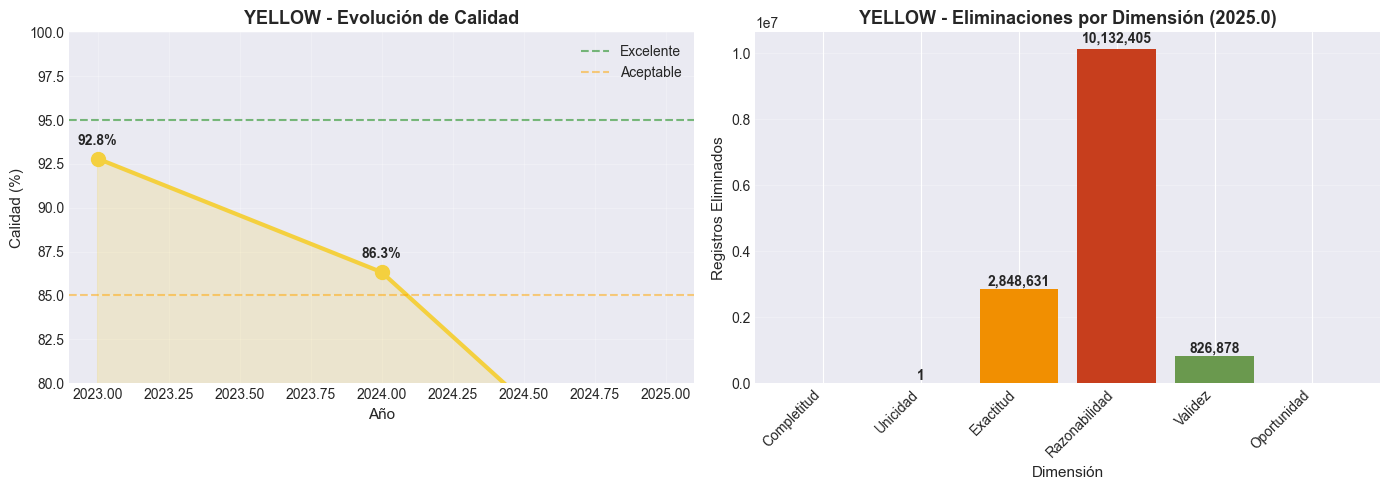


 GREEN

 Resumen por Año:
 Año  Original  Final  Eliminados  Eliminado %  Completitud  Unicidad  Exactitud  Razonabilidad  Validez  Oportunidad
2023    787060 683391      103669        13.17            0         0       2217          97257     4195            0
2024    660218 591547       68671        10.40            0         0       2144          62486     4041            0
2025    591375 507995       83380        14.10            0         0       1736          77340     4304            0


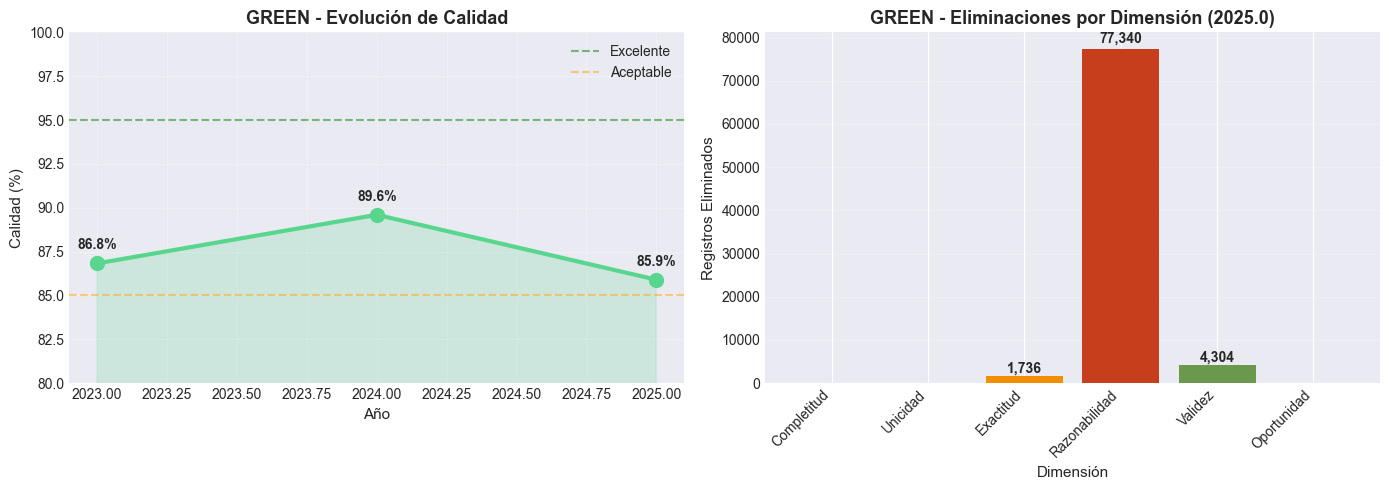


 FHV

 Resumen por Año:
 Año  Original    Final  Eliminados  Eliminado %  Completitud  Unicidad  Exactitud  Razonabilidad  Validez  Oportunidad
2023  15858639 15519045      339594         2.14            0    339594          0              0        0            0
2024  17630326 17175195      455131         2.58            0    455131          0              0        0            0
2025  25047544 24440543      607001         2.42            0    607001          0              0        0            0


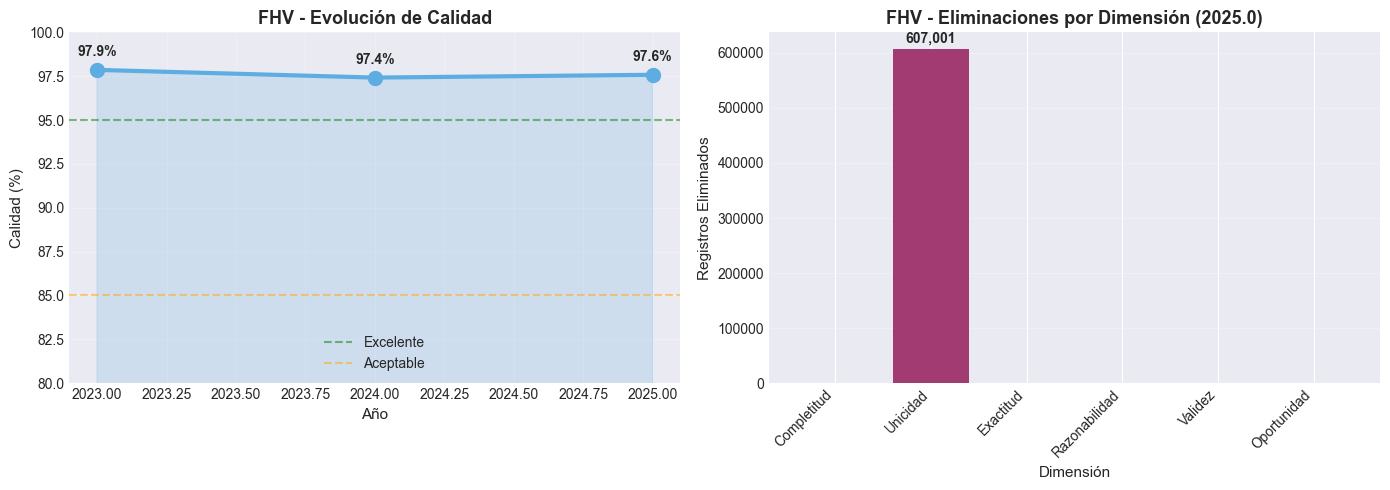


 FHVHV (EXCLUIDO)
    Sin datos disponibles para este tipo


In [16]:
# ============================================================
# 2. ANÁLISIS DETALLADO POR TIPO DE TAXI
# ============================================================

print("=" * 80)
print(" 2. ANÁLISIS DETALLADO POR TIPO DE TAXI")
print("=" * 80)

for taxi_type in TAXI_TYPES:
    if taxi_type not in ALL_REPORTS:
        continue
    
    years_data = ALL_REPORTS[taxi_type]
    is_excluded = taxi_type in EXCLUDED_TYPES
    
    print(f"\n{'='*70}")
    print(f" {taxi_type.upper()}" + (" (EXCLUIDO)" if is_excluded else ""))
    print(f"{'='*70}")
    
    # Datos por año
    year_summary = []
    for year, report in years_data.items():
        dimensions = report.get('dimensions', {})
        removed_by_dim = {}
        for dim in QUALITY_DIMENSIONS:
            removed_by_dim[DIMENSION_LABELS[dim]] = dimensions.get(dim, {}).get('records_removed', 0)
        
        year_summary.append({
            'Año': year,
            'Original': report.get('original_records', 0),
            'Final': report.get('final_records', 0),
            'Eliminados': report.get('records_removed', 0),
            'Eliminado %': report.get('removed_percentage', 0),
            **removed_by_dim
        })
    
    # Verificar si hay datos
    if not year_summary:
        print("    Sin datos disponibles para este tipo")
        continue
    
    df_year = pd.DataFrame(year_summary)
    
    print("\n Resumen por Año:")
    print(df_year.to_string(index=False))
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Evolución de calidad
    ax1 = axes[0]
    quality = [100 - row['Eliminado %'] for _, row in df_year.iterrows()]
    years = df_year['Año'].tolist()
    
    ax1.plot(years, quality, marker='o', linewidth=3, markersize=10,
             color=COLORS.get(taxi_type, COLORS['primary']))
    ax1.fill_between(years, quality, alpha=0.2, color=COLORS.get(taxi_type, COLORS['primary']))
    ax1.set_title(f'{taxi_type.upper()} - Evolución de Calidad', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Año', fontsize=11)
    ax1.set_ylabel('Calidad (%)', fontsize=11)
    ax1.axhline(y=95, color='green', linestyle='--', alpha=0.5, label='Excelente')
    ax1.axhline(y=85, color='orange', linestyle='--', alpha=0.5, label='Aceptable')
    ax1.legend()
    ax1.grid(True, alpha=0.25)
    ax1.set_ylim(80, 100)
    
    for x, y in zip(years, quality):
        ax1.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontweight='bold')
    
    # Gráfico 2: Desglose de eliminaciones por dimensión (último año)
    ax2 = axes[1]
    last_year = df_year.iloc[-1]
    # Obtener solo las columnas de dimensiones (excluir Año, Original, Final, Eliminados, Eliminado %)
    dim_cols = [col for col in df_year.columns if col in DIMENSION_LABELS.values()]
    values = [last_year[dim] for dim in dim_cols]
    
    if dim_cols and any(v > 0 for v in values):
        colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#5DADE2'][:len(dim_cols)]
        bars = ax2.bar(dim_cols, values, color=colors)
        ax2.set_title(f'{taxi_type.upper()} - Eliminaciones por Dimensión ({last_year["Año"]})', 
                      fontsize=13, fontweight='bold')
        ax2.set_xlabel('Dimensión', fontsize=11)
        ax2.set_ylabel('Registros Eliminados', fontsize=11)
        ax2.set_xticks(range(len(dim_cols)))
        ax2.set_xticklabels(dim_cols, rotation=45, ha='right')
        ax2.grid(axis='y', alpha=0.25)
        
        for bar, val in zip(bars, values):
            if val > 0:
                ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+val*0.01,
                        f'{val:,.0f}', ha='center', va='bottom', fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'Sin datos de dimensiones o todas cero', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.set_title(f'{taxi_type.upper()} - Sin datos de dimensiones', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

In [21]:
# ============================================================
# 3. RESUMEN EJECUTIVO FINAL
# ============================================================

print("=" * 80)
print(" 3. RESUMEN EJECUTIVO - RESULTADOS DE LIMPIEZA")
print("=" * 80)

# Estadísticas globales
total_original = 0
total_removed = 0
total_final = 0

for taxi_type, years_data in ALL_REPORTS.items():
    for year, report in years_data.items():
        total_original += report.get('original_records', 0)
        total_removed += report.get('records_removed', 0)
        total_final += report.get('final_records', 0)

print(f"\n ESTADÍSTICAS GLOBALES:")
print(f"   • Total registros originales: {total_original:,}")
print(f"   • Total registros eliminados: {total_removed:,}")
print(f"   • Total registros finales: {total_final:,}")

if total_original > 0:
    print(f"   • Porcentaje eliminado: {(total_removed/total_original*100):.2f}%")
    print(f"   • Calidad global: {(total_final/total_original*100):.2f}%")
else:
    print("   • No hay datos para calcular porcentajes")

# Calcular efectividad de dimensiones desde los reportes
dim_effectiveness = {}
for taxi_type, years_data in ALL_REPORTS.items():
    for year, report in years_data.items():
        dimensions = report.get('dimensions', {})
        for dim, info in dimensions.items():
            if dim in QUALITY_DIMENSIONS:
                removed = info.get('records_removed', 0)
                if dim not in dim_effectiveness:
                    dim_effectiveness[dim] = 0
                dim_effectiveness[dim] += removed

print(f"\n DIMENSIONES DE CALIDAD APLICADAS:")
if dim_effectiveness:
    for dim in QUALITY_DIMENSIONS:
        label = DIMENSION_LABELS.get(dim, dim)
        count = dim_effectiveness.get(dim, 0)
        pct = count / total_removed * 100 if total_removed > 0 else 0
        print(f"   • {label}: {count:,} registros ({pct:.1f}% del total)")
else:
    print("   • No hay datos de dimensiones disponibles")

print(f"\n RECOMENDACIONES:")

# Calcular calidad por tipo desde los reportes
type_quality = []
for taxi_type, years_data in ALL_REPORTS.items():
    if not years_data:
        continue
    avg_removed = np.mean([y.get('removed_percentage', 0) for y in years_data.values()])
    avg_quality = 100 - avg_removed
    is_excluded = taxi_type in EXCLUDED_TYPES
    type_quality.append({
        'Tipo': taxi_type.upper(),
        'Calidad': avg_quality,
        'Estado': 'EXCLUIDO' if is_excluded else 'ACTIVO'
    })

if type_quality:
    df_type_quality = pd.DataFrame(type_quality)
    df_active = df_type_quality[df_type_quality['Estado'] == 'ACTIVO']
    
    if not df_active.empty:
        peor = df_active.loc[df_active['Calidad'].idxmin()]
        mejor = df_active.loc[df_active['Calidad'].idxmax()]
        print(f"   • Mejor calidad: {mejor['Tipo']} ({mejor['Calidad']:.1f}%)")
        print(f"   • Priorizar revisión de {peor['Tipo']} (calidad más baja: {peor['Calidad']:.1f}%)")

# Identificar dimensión más efectiva
if dim_effectiveness:
    top_dim = max(dim_effectiveness, key=dim_effectiveness.get)
    top_count = dim_effectiveness[top_dim]
    print(f"   • Dimensión más efectiva: {DIMENSION_LABELS.get(top_dim, top_dim)} ({top_count:,.0f} registros)")

# Tipos excluidos
excluded_types = [t for t in TAXI_TYPES if t in EXCLUDED_TYPES and t in ALL_REPORTS]
if excluded_types:
    print(f"\n TIPOS EXCLUIDOS DEL PIPELINE:")
    for t in excluded_types:
        print(f"   • {t.upper()}: No incluido en procesamiento estándar")

print(f"\n UBICACIÓN DE ARCHIVOS:")
print(f"   • Reportes de calidad: {QUALITY_DIR}")
print(f"   • Datos procesados: {OUTPUT_DIR}")
print("=" * 80)
print(" ANÁLISIS COMPLETADO")
print(f"   Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

 3. RESUMEN EJECUTIVO - RESULTADOS DE LIMPIEZA

 ESTADÍSTICAS GLOBALES:
   • Total registros originales: 188,777,710
   • Total registros eliminados: 23,851,067
   • Total registros finales: 164,926,643
   • Porcentaje eliminado: 12.63%
   • Calidad global: 87.37%

 DIMENSIONES DE CALIDAD APLICADAS:
   • Completitud: 0 registros (0.0% del total)
   • Unicidad: 1,401,733 registros (5.9% del total)
   • Exactitud: 3,967,436 registros (16.6% del total)
   • Razonabilidad: 16,736,024 registros (70.2% del total)
   • Validez: 1,745,874 registros (7.3% del total)
   • Oportunidad: 0 registros (0.0% del total)

 RECOMENDACIONES:
   • Mejor calidad: FHV (97.6%)
   • Priorizar revisión de YELLOW (calidad más baja: 83.6%)
   • Dimensión más efectiva: Razonabilidad (16,736,024 registros)

 TIPOS EXCLUIDOS DEL PIPELINE:
   • FHVHV: No incluido en procesamiento estándar

 UBICACIÓN DE ARCHIVOS:
   • Reportes de calidad: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Mas